In [1]:
# --! include root folders into PYTHONPATH --!

import os
import sys

dir_this = os.getcwd()
dir_example = os.path.abspath(os.path.join(dir_this, '..'))
sys.path.append(dir_example)
dir_root = os.path.abspath(os.path.join(dir_this, '..', '..', '..'))
sys.path.append(dir_root)

import torch
import torch.nn.functional as F
import numpy as np
from matplotlib import pyplot as plt

import example_mujoco
import util_data
import util_nn

data_path = '../../../data/mujoco'
model_path = '../../../models/mujoco'
result_path = '../../../results/mujoco'

### Creating baseline dataset

In [2]:
data_nsample = 918
data = util_data.read_datafile(f'{data_path}/walker2d_baseline_0', data_nsample)
print(f'read data shape: {data.shape}')

obs_ndim = 17
act_ndim = 6
obs, act = torch.split(data, [obs_ndim, act_ndim], dim=-1)
print(f'read observations shape: {obs.shape}')
print(f'read actions shape: {act.shape}')

std_min = torch.tensor(1e-3, dtype=torch.float32)

# --! get normalization constants per observation
obs_mean = [s.mean() for s in torch.split(obs, 1, dim=-1)]
obs_std = [torch.maximum(s.std(), std_min) for s in torch.split(obs, 1, dim=-1)]

# --! normalize observations
obs = torch.cat([
    example_mujoco.normalize_standard(
        s, mean, std) for s, mean, std in zip(torch.split(obs, 1, dim=-1), obs_mean, obs_std)], dim=-1)

train_obs = obs[:, :-1]
train_next_obs = obs[:, 1:]
train_act = act[:, :-1]
print(f'shape of observations for training: {train_obs.shape}')
print(f'shape of next observations for training: {train_next_obs.shape}')
print(f'shape of actions for training: {train_act.shape}')

dataloaders = []
nmodel = 5

for _ in range(nmodel):
    dataset = example_mujoco.baseline_dataset(train_obs, train_act, train_next_obs)
    dataloaders.append(torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True))

read data shape: torch.Size([80, 918, 23])
read observations shape: torch.Size([80, 918, 17])
read actions shape: torch.Size([80, 918, 6])
shape of observations for training: torch.Size([80, 917, 17])
shape of next observations for training: torch.Size([80, 917, 17])
shape of actions for training: torch.Size([80, 917, 6])


### Training an ensemble of models

In [3]:
model = example_mujoco.model_ensemble(nmodel, obs_ndim, act_ndim)
example_mujoco.train_ensemble(model, dataloaders, nepoch=300)

0 [array([-0.06831803]), array([-0.07214156]), array([-0.0678256]), array([-0.06782666]), array([-0.06645218])]
10 [array([-0.23197434]), array([-0.24099967]), array([-0.22966094]), array([-0.24383845]), array([-0.19658992])]
20 [array([-0.50299091]), array([-0.53155503]), array([-0.52844176]), array([-0.52806411]), array([-0.48220158])]
30 [array([-0.65244322]), array([-0.59540896]), array([-0.61976581]), array([-0.59385962]), array([-0.58927808])]
40 [array([-0.69093165]), array([-0.68873258]), array([-0.67467885]), array([-0.69311676]), array([-0.68843327])]
50 [array([-0.56001678]), array([-0.6506783]), array([-0.67680478]), array([-0.68280015]), array([-0.70274534])]
60 [array([-0.73688354]), array([-0.75304503]), array([-0.74720225]), array([-0.64114599]), array([-0.72789083])]
70 [array([-0.65363736]), array([-0.77412825]), array([-0.77939959]), array([-0.74452777]), array([-0.73444929])]
80 [array([-0.75946503]), array([-0.78093905]), array([-0.45249214]), array([-0.76552167]),

# Evaluating ensemble baseline

In [4]:
eval_data = util_data.read_datafile(f'{data_path}/walker2d_eval_0', data_nsample)
print(f'read evaluation data shape: {eval_data.shape}')

eval_obs, eval_act = torch.split(eval_data, [obs_ndim, act_ndim], dim=-1)
print(f'read evaluation observations shape: {eval_obs.shape}')
print(f'read evaluation actions shape: {eval_act.shape}')

# --! normalize evaluation data
eval_obs = torch.cat([
    example_mujoco.normalize_standard(
        s, mean, std) for s, mean, std in zip(torch.split(eval_obs, 1, dim=-1), obs_mean, obs_std)], dim=-1)

read evaluation data shape: torch.Size([30, 918, 23])
read evaluation observations shape: torch.Size([30, 918, 17])
read evaluation actions shape: torch.Size([30, 918, 6])


In [9]:
this_traj = 17
deterministic = True
reanchor_nsample = 1_000

s0 = eval_obs[this_traj, 0]
rollout_traj = example_mujoco.rollout_ensemble(
    model, s0,
    eval_obs[this_traj], eval_act[this_traj],
    deterministic=deterministic, reanchor_nsample=reanchor_nsample)
print(f'rollout shape: {rollout_traj.shape}')

rollout shape: torch.Size([919, 17])


### Plotting rollout results

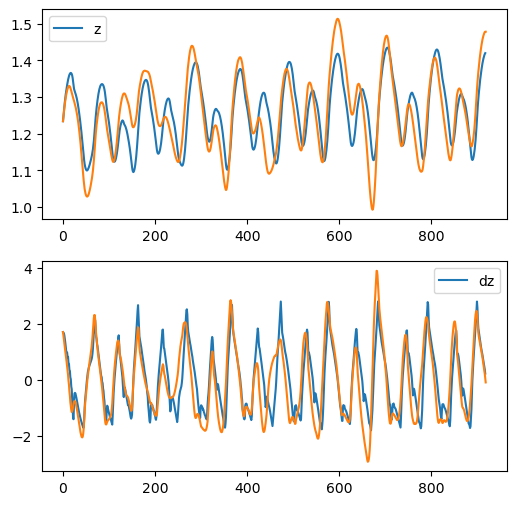

In [10]:
disp_end = rollout_traj.shape[0]
datasaved = False

plot_obs, plot_rollout = example_mujoco.disp_rollout(eval_obs, rollout_traj, obs_mean, obs_std, this_traj, disp_end)

if datasaved:
    rollout_type = 'deterministic' if deterministic else 'stochastic'
    save_step = torch.arange(eval_obs.shape[1]).reshape(1, -1, 1)
    savedata = np.concatenate([
        save_step[:1, :disp_end, :1],
        plot_obs[:1, :disp_end, :1], plot_obs[:1, :disp_end, [9]],
        plot_rollout[:1, :disp_end, :1], plot_rollout[:1, :disp_end, [9]]], axis=2)
    util_data.write_datafile(f'{result_path}/walker2d_ensemble_rollout_{rollout_type}', savedata, delim=' ')

In [7]:
traj_mse = []
with torch.no_grad():
    for j in range(eval_obs.shape[0]): # trajectory
        print(f'processing trajectory {j+1} out of {eval_obs.shape[0]}')
        mse = []
        for h in range(1, eval_obs.shape[1]): # horizon
            s0 = eval_obs[j, 0]
            cmp_rollout = example_mujoco.rollout_ensemble(
                model, s0,
                eval_obs[j, :h], eval_act[j, :h],
                deterministic=False, reanchor_nsample=reanchor_nsample)

            # --! denormalize results
            cmp_rollout = torch.unsqueeze(cmp_rollout, 0)
            cmp_rollout = torch.cat([
                example_mujoco.denormalize_standard(
                    s, mean, std) for s, mean, std in zip(torch.split(cmp_rollout, 1, dim=-1), obs_mean, obs_std)], dim=-1)
            cmp_obs = torch.cat([
                example_mujoco.denormalize_standard(
                    s, mean, std) for s, mean, std in zip(torch.split(eval_obs[[j], :(h+1)], 1, dim=-1), obs_mean, obs_std)], dim=-1)

            # --! compute error
            loss = F.mse_loss(cmp_rollout, cmp_obs)
            mse.append(loss)
            if h % 100 == 0:
                print(f'\thorizon {h} out of {eval_obs.shape[1]}, loss: {loss}')
        mse = torch.stack(mse)
        traj_mse.append(mse)
    traj_mse = torch.stack(traj_mse)


processing trajectory 1 out of 30
	horizon 100 out of 918, loss: 10.540657997131348
	horizon 200 out of 918, loss: 10.093725204467773
	horizon 300 out of 918, loss: 9.468137741088867
	horizon 400 out of 918, loss: 10.260284423828125
	horizon 500 out of 918, loss: 10.830016136169434
	horizon 600 out of 918, loss: 10.565753936767578
	horizon 700 out of 918, loss: 22.744131088256836
	horizon 800 out of 918, loss: 106.98130798339844
	horizon 900 out of 918, loss: 11.372115135192871
processing trajectory 2 out of 30
	horizon 100 out of 918, loss: 8.303021430969238
	horizon 200 out of 918, loss: 13.69266414642334
	horizon 300 out of 918, loss: 19.33878517150879
	horizon 400 out of 918, loss: 13.822360038757324
	horizon 500 out of 918, loss: 9.27843189239502
	horizon 600 out of 918, loss: 35.63872528076172
	horizon 700 out of 918, loss: 9.82813835144043
	horizon 800 out of 918, loss: 11.22258472442627
	horizon 900 out of 918, loss: 34.545597076416016
processing trajectory 3 out of 30
	horizon

tensor(0.6859)
tensor(0.6899)


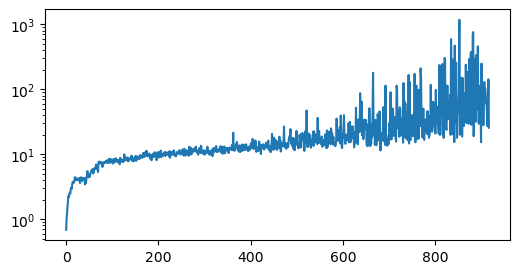

In [8]:
traj_mse_mean = torch.mean(traj_mse, dim=0)
traj_mse_std = torch.std(traj_mse, dim=0)

print(traj_mse_mean[0])
print(traj_mse_std[0])

with torch.no_grad():
    plt.figure(figsize=(6,3))
    plt.semilogy(traj_mse_mean)
    plt.show()

datasaved = False
if datasaved:
    rollout_type = 'deterministic' if deterministic else 'stochastic'
    save_mse_mean = traj_mse_mean.reshape(1, -1, 1)
    save_mse_std = traj_mse_std.reshape(1, -1, 1)
    save_step = torch.arange(traj_mse_mean.shape[0]).reshape(1, -1, 1)
    savedata = np.concatenate([
        save_step[:1, :, :1],
        save_mse_mean[:1, :, :1], save_mse_std[:1, :, :1]], axis=2)
    util_data.write_datafile(f'{result_path}/walker2d_ensemble_mse_{rollout_type}', savedata, delim=' ')